**Agenda:**



1.   Introduction to Yolo
2.   Perform object detection using a pre-trained Yolo models
3.   Train a Yolo model on a custom dataset



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


YOLO (You Only Look Once)



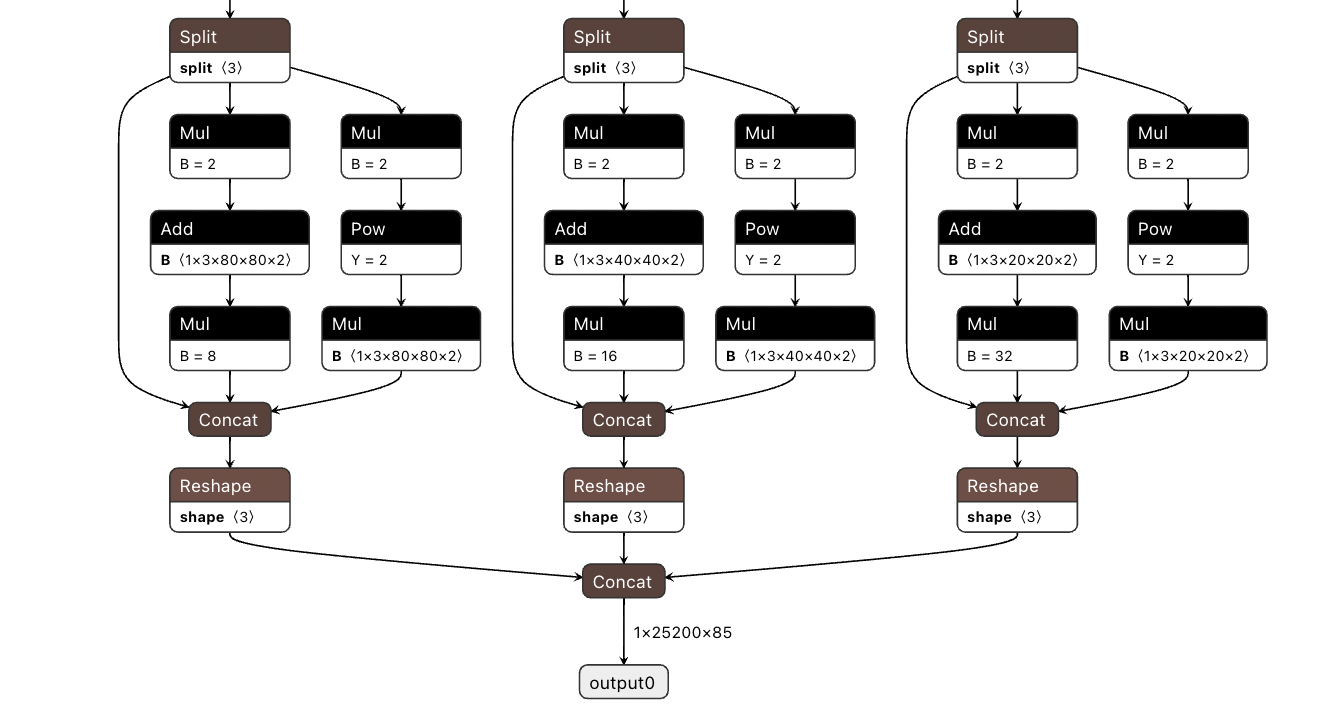

1.   Proposed in 2015 by Joseph Redmon, Santosh Divvala, Ross Girshick, Ali Farhadi
2.   Convolutional Neural Network based backbone network.
3.   YOLOV8, released in January 2023, YOLO11 in 2024 and YOLO12 in 2025. YOLO12 is the latest release of this family.
4.   Originally meant for *object detection* but evolved to perform
    *   Image Classification
    *   Image Segmentation as well
5. The different neural networks in the family are available as Pytorch implementation.
6.    Specifically the following implementations are available


**Classification**	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> **Detection**	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> **Segmentation**	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> **Kind** \\

yolov8n-cls.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8n.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8n-seg.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> Nano \\

yolov8s-cls.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8s.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8s-seg.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> Small \\

yolov8m-cls.pt	<code>&nbsp;&nbsp;&nbsp;</code> yolov8m.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8m-seg.pt	<code>&nbsp;&nbsp;&nbsp;</code> Medium \\

yolov8l-cls.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp; </code> yolov8l.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;  </code> yolov8l-seg.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> Large \\

yolov8x-cls.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8x.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> yolov8x-seg.pt	<code>&nbsp;&nbsp;&nbsp;&nbsp;</code> Huge \\


7.    Depending upon the task and the degree of accuracy required, corresponding weights of the YOLO-V8 model can be downloaded and used for making inferences.
    *     All the above models have been trained on the COCO dataset
    *     Usually more complex the model, the better its accuracy and slower its performance.






In [2]:
# Install the ultralytics package. This package contains the implementation of Yolo models

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.9 MB/s eta 0:00:00


In [3]:
# Import the YOLO class from the ultralytics package. YOLO is the class responsible for creating different neural networks

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Mount the Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Agend 2:**

1.   Perform object detection using an already pre-trained YOLOV8 model on a sample image
2.   Analyze the predictions made by the model



In [4]:
# Load the YOLO model; the model weights will be downloaded upon first run when creating the model object

model = YOLO("yolov8m.pt") # medium sized

In [5]:
# Getting the model architecture (for exploratory analysis)

print("Model architecture: \n\n", model, "\n\n")
print("type(model): \t", type(model), "\n")

Model architecture: 

 YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affi

In [6]:
# Import basic Python libraries

import numpy as np
import cv2      #OpenCV for basic image processing tasks
import matplotlib.pyplot as plt

# Import Pytorch as most of the data items will be in the form of Pytorch Tensors

import torch

test_image.shape: 	 (415, 612, 3) 

Sample test image: 



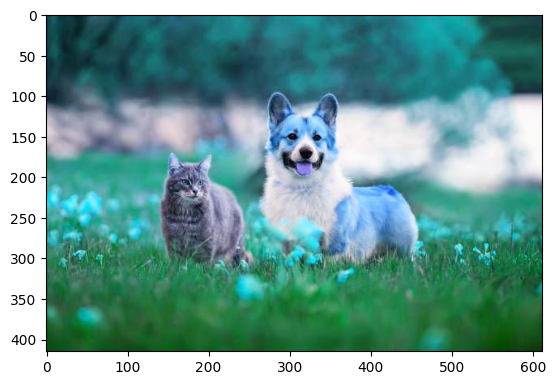

In [ ]:
# Set the path of the test image and load the sample test image

test_image_path = '/content/drive/MyDrive/Module 2 - Google Colab files/cat_dog.jpg'
test_image = cv2.imread(test_image_path)

print("test_image.shape: \t", test_image.shape, "\n")

# Display the image read

print("Sample test image: \n")
plt.imshow(test_image)

In [ ]:
# Now detect the objects in the image

results = model.predict(test_image)
print("\ntype(results): \t", type(results), "\n\n")


0: 448x640 1 cat, 1 dog, 99.6ms
Speed: 15.0ms preprocess, 99.6ms inference, 46.8ms postprocess per image at shape (1, 3, 448, 640)

type(results): 	 <class 'list'> 




In [ ]:
print("Object Detection Results: \n", results, "\n")
print("len(results): \t", len(results), "\n")

Object Detection Results: 
 [ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57:

In [ ]:
# Getting the result from the model;

result = results[0]
print("result: \n", result, "\n")

result: 
 ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'pott

In [ ]:
# The result contains different attributes returned by the YOLO-V8 model; let's analyze them one by one

# Getting the different object categories that the model can detect

class_names = result.names
print("type(class_names): \t", type(class_names), "\n")
print("The model can detect ", len(class_names), " different object categories \n")

# let's get all the object categorires and their class IDs neatly

print("Class ID: \t Object Class Name \n")
for key in class_names.keys():
    print(key, "\t\t", class_names[key])

type(class_names): 	 <class 'dict'> 

The model can detect  80  different object categories 

Class ID: 	 Object Class Name 

0 		 person
1 		 bicycle
2 		 car
3 		 motorcycle
4 		 airplane
5 		 bus
6 		 train
7 		 truck
8 		 boat
9 		 traffic light
10 		 fire hydrant
11 		 stop sign
12 		 parking meter
13 		 bench
14 		 bird
15 		 cat
16 		 dog
17 		 horse
18 		 sheep
19 		 cow
20 		 elephant
21 		 bear
22 		 zebra
23 		 giraffe
24 		 backpack
25 		 umbrella
26 		 handbag
27 		 tie
28 		 suitcase
29 		 frisbee
30 		 skis
31 		 snowboard
32 		 sports ball
33 		 kite
34 		 baseball bat
35 		 baseball glove
36 		 skateboard
37 		 surfboard
38 		 tennis racket
39 		 bottle
40 		 wine glass
41 		 cup
42 		 fork
43 		 knife
44 		 spoon
45 		 bowl
46 		 banana
47 		 apple
48 		 sandwich
49 		 orange
50 		 broccoli
51 		 carrot
52 		 hot dog
53 		 pizza
54 		 donut
55 		 cake
56 		 chair
57 		 couch
58 		 potted plant
59 		 bed
60 		 dining table
61 		 toilet
62 		 tv
63 		 laptop
64 		 mouse

original_test_image.shape: 	 (415, 612, 3) 



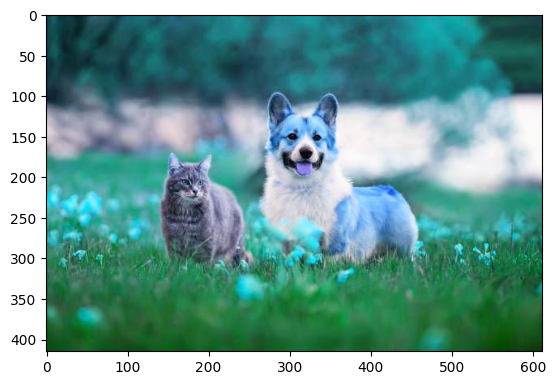

In [ ]:
# Let's get the test image passed to the model

original_test_image = result.orig_img
print("original_test_image.shape: \t", original_test_image.shape, "\n")

original_test_image_copy = original_test_image

plt.imshow(original_test_image)

In [ ]:
# Let's analyze the computation time taken by the model

computation_time = result.speed
print("type(computation_time): \t", type(computation_time), "\n\n")

# Let's get the computation information neatly
print("Task \t\t Time Taken \n")
for key in computation_time.keys():
    print(key, "\t", computation_time[key])

type(computation_time): 	 <class 'dict'> 


Task 		 Time Taken 

preprocess 	 14.958215000007158
inference 	 99.55988999999477
postprocess 	 46.787620999992896


In [ ]:
# Let's analyze the bounding box returned by the model

bounding_box_predictions = result.boxes
print("type(bounding_box_predictions) \t", type(bounding_box_predictions), "\n\n")
print("bounding_box_predictions: \n", bounding_box_predictions, "\n")

type(bounding_box_predictions) 	 <class 'ultralytics.engine.results.Boxes'> 


bounding_box_predictions: 
 ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16., 15.], device='cuda:0')
conf: tensor([0.9450, 0.9131], device='cuda:0')
data: tensor([[261.0996,  94.0881, 460.9550, 313.6855,   0.9450,  16.0000],
        [140.2444, 169.6616, 256.3775, 315.4379,   0.9131,  15.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (415, 612)
shape: torch.Size([2, 6])
xywh: tensor([[361.0273, 203.8868, 199.8554, 219.5974],
        [198.3109, 242.5497, 116.1331, 145.7763]], device='cuda:0')
xywhn: tensor([[0.5899, 0.4913, 0.3266, 0.5292],
        [0.3240, 0.5845, 0.1898, 0.3513]], device='cuda:0')
xyxy: tensor([[261.0996,  94.0881, 460.9550, 313.6855],
        [140.2444, 169.6616, 256.3775, 315.4379]], device='cuda:0')
xyxyn: tensor([[0.4266, 0.2267, 0.7532, 0.7559],
        [0.2292, 0.4088, 0.4189, 0.7601]], device='cuda:0') 



In [ ]:
# Set display options; this step is optional

torch.set_printoptions(precision=2, sci_mode=None)
np.set_printoptions(precision=2, suppress=None)

type(bounding_box_xyxy_coordinates):  <class 'torch.Tensor'> 

Number of bounding boxes detected: 	 2 

Showing box:  1 



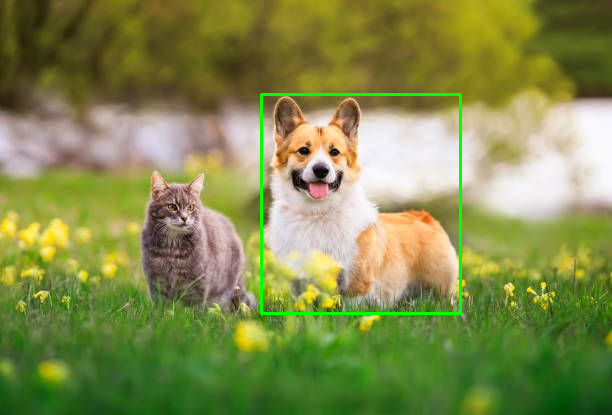




Showing box:  2 



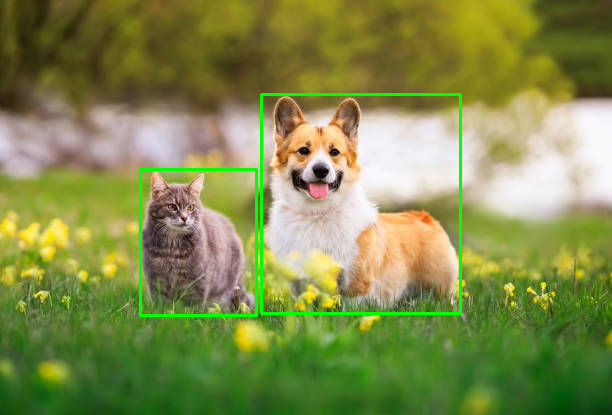

In [ ]:
# Let's analyze the bounding box returned by the model
# Let's draw a bounding box around the image
from google.colab.patches import cv2_imshow

bounding_box_xyxy_coordinates = bounding_box_predictions.xyxy
print("type(bounding_box_xyxy_coordinates): ", type(bounding_box_xyxy_coordinates),"\n")

bounding_box_xyxy_coordinates_list = bounding_box_xyxy_coordinates.tolist()
print("Number of bounding boxes detected: \t", len(bounding_box_xyxy_coordinates_list), "\n")

for box_index in range(len(bounding_box_xyxy_coordinates_list)):
    print("Showing box: ", box_index+1, "\n")
    x1, y1, x2, y2 = bounding_box_xyxy_coordinates_list[box_index]
    x1 = int(x1)
    x2 = int(x2)
    y1 = int(y1)
    y2 = int(y2)
    cv2.rectangle(original_test_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2_imshow(original_test_image)
    print("\n\n")

**Agenda 3:**

Training the YOLOV8 model on a custom dataset

**Step: 1 Dataset Preparation**

1.    Prepare the images and their annotations and split them in two folders namely, train and val (following let's say a 80/20 split).
2.    Additionally, a separate test folder may also be created for making inferences [Optional].
3.    In each of the the above two folders (train and val), create two folders namely, images and labels for storing corresponding values
4.    For each image int he images folder, create an annotation file in the labels subfolder.
*    Annotation text files should have the same name as the image filename and with a .txt extension
*    This txt file should be annotated in the following format \\

       <center>{class_id} {x_center} {y_center} {width} {height}</center>
* Note: The bounding box coordinates must be normalized to be in [0,1]
*    <center>x_center = (box_left + box_x_width/2)/image_width</center>
*    <center>y_center = (box_y_top + box_height/2)/image_height</center>
*    <center>width = box_width / image_width</center>
*    <center>height = box_height / image_height </center>

**Step 2: Create a YAML file**
1.    Create a dataset descriptor YAML file; this should point to the annotated datasets
2.    This YAML file is eventually passed to the train function

**Step 3: Train the model using the YAML file created in the above step.**


In [8]:
model.train(data="/content/drive/MyDrive/road_signs/data2.yaml", epochs=1)

Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/road_signs/data2.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, pl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f69255376e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0